## Data Import

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
data_path = Path("../../data/final_pairs_with_error_labels_WIP_for_INSPECTIONs.xlsx")

In [5]:
labelled_df = pd.read_excel(data_path)
print(f"dataset shape: {labelled_df.shape}")
labelled_df.head(5)

dataset shape: (3468, 3)


,correct,incorrect,error_type
0,apennines,apenines,missing_letter
1,apennines,appenines,complex/multiple
2,athenian,athenean,phoneme_substitution
3,athenians,atheneans,phoneme_substitution
4,bernoulli,bernouilli,extra_letter


In [7]:
labelled_df['error_type'].value_counts().sort_values()

error_type
substitution             246
extra_letter             493
phoneme_substitution     653
complex/multiple        1029
missing_letter          1047
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labelled_df['error_type_encoded'] = label_encoder.fit_transform(labelled_df['error_type'])

labelled_df['error_type_encoded'].value_counts().sort_values()

error_type_encoded
4     246
1     493
3     653
0    1029
2    1047
Name: count, dtype: int64

In [14]:
labelled_df.head(5)

,correct,incorrect,error_type,error_type_encoded
0,apennines,apenines,missing_letter,2
1,apennines,appenines,complex/multiple,0
2,athenian,athenean,phoneme_substitution,3
3,athenians,atheneans,phoneme_substitution,3
4,bernoulli,bernouilli,extra_letter,1


### create pair and label lists

In [11]:
pairs = []
labels = []

for index, row in labelled_df.iterrows():
    pairs.append((row['correct'], row['incorrect']))
    labels.append(row['error_type_encoded'])

print(f"Total pairs: {len(pairs)}")
print(f"Total labels: {len(labels)}")

Total pairs: 3468
Total labels: 3468


In [13]:
# preview the first 5 pairs and their corresponding labels
print(pairs[:5])
print(labels[:5])

[('apennines', 'apenines'), ('apennines', 'appenines'), ('athenian', 'athenean'), ('athenians', 'atheneans'), ('bernoulli', 'bernouilli')]
[2, 0, 3, 3, 1]


## Model 1: BiLSTM

### Character tokenizer

example:

"friend" + \<SEP\> + "frend"  →  [f, r, i, e, n, d, \<SEP\>, f, r, e, n, d]
                              →  [5, 9, 7, 4, 11, 3, 1, 5, 9, 4, 11, 3]

In [15]:
PAD_IDX = 0
SEP_IDX = 1

class CharTokenizer:
    def __init__(self):
        self.char2idx = {"<PAD>": PAD_IDX, "<SEP>": SEP_IDX}

    def fit(self, words):
        for word in words:
            for ch in word.lower():
                if ch not in self.char2idx:
                    self.char2idx[ch] = len(self.char2idx)
        return self

    def encode_pair(self, correct, incorrect):
        encode = lambda w: [self.char2idx.get(ch, PAD_IDX) for ch in w.lower()]
        return encode(correct) + [SEP_IDX] + encode(incorrect)

    @property
    def vocab_size(self):
        return len(self.char2idx)


all_words  = [w for pair in pairs for w in pair]
tokenizer  = CharTokenizer().fit(all_words)

### Train Test Split

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class PairDataset(Dataset):
    def __init__(self, pairs, labels, tokenizer):
        # encode every pair once at construction time
        self.sequences = [tokenizer.encode_pair(c, i) for c, i in pairs]
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # returns a variable-length list and a scalar int
        return self.sequences[idx], self.labels[idx]


def collate_fn(batch):
    """Pad sequences in a batch to the same length.
    This is needed because the sequences are variable-length, 
    and we need to create a tensor of shape (batch_size, max_seq_len) for the model."""
    
    seqs, labels = zip(*batch)
    max_len = max(len(s) for s in seqs)
    padded  = [s + [PAD_IDX] * (max_len - len(s)) for s in seqs]
    return (
        torch.tensor(padded, dtype=torch.long),   # (batch, max_len)
        torch.tensor(labels, dtype=torch.long),   # (batch,)
    )


In [17]:
# train/val split
from sklearn.model_selection import train_test_split

train_pairs, val_pairs, train_labels, val_labels = train_test_split(
    pairs, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = PairDataset(train_pairs, train_labels, tokenizer)
val_dataset   = PairDataset(val_pairs,   val_labels,   tokenizer)

train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  collate_fn=collate_fn)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, collate_fn=collate_fn)

In [22]:
# preview the first 5 sequences in the training dataset
print(train_dataset.sequences[:5])

# preview the first 5 labels in the training dataset
print(train_dataset.labels[:5])

[[19, 2, 5, 12, 4, 13, 28, 11, 2, 10, 6, 14, 6, 8, 21, 1, 19, 2, 5, 12, 4, 13, 28, 4, 11, 2, 10, 6, 14, 6, 8, 21], [7, 2, 8, 4, 14, 14, 6, 8, 4, 7, 1, 7, 2, 8, 8, 4, 14, 6, 8, 4, 7], [7, 8, 11, 12, 5, 17, 4, 7, 8, 1, 7, 8, 12, 11, 5, 4, 17, 7, 8], [28, 12, 14, 13, 5, 8, 4, 4, 11, 6, 5, 17, 1, 28, 12, 14, 12, 5, 8, 4, 4, 11, 6, 5, 17], [6, 11, 11, 4, 7, 6, 7, 8, 6, 10, 14, 4, 1, 6, 11, 11, 4, 7, 6, 7, 8, 2, 10, 14, 4]]
[1, 0, 0, 3, 3]


### Define Model Archetecture

In [24]:
import torch.nn as nn
import torch.nn.functional as F

class Model1_BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64,
                 num_layers=2, num_classes=5, dropout=0.3):
        super().__init__()

        # maps each char index -> dense vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # bidirectional LSTM processes the sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,       # input shape: (batch, seq, features)
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_dim * 2, hidden_dim)  # this function maps the concatenated forward and backward hidden states to a smaller hidden dimension
        self.fc2     = nn.Linear(hidden_dim, num_classes)     # this function maps the smaller hidden dimension to the number of classes (error types)

    def forward(self, x):
        # x: (batch, seq_len)

        emb = self.dropout(self.embedding(x))    # (batch, seq_len, embed_dim)

        # # self.lstm returns a tuple: (output, (h_n, c_n)); 
        # output is the hidden states for all time steps (we don't need these), 
        # h_n is the hidden state for the last time step/layer (this we want for training), 
        # and c_n is the cell state for the last time step (don't need this)
        
        _, (h_n, _) = self.lstm(emb)    # h_n: (num_layers * 2, batch, hidden_dim)
        h_fwd = h_n[-2]                          # (batch, hidden_dim); this is the last layer's forward hidden state
        h_bwd = h_n[-1]                          # (batch, hidden_dim); this is the last layer's backward hidden state
        h     = torch.cat([h_fwd, h_bwd], dim=1) # (batch, hidden_dim * 2); concatenated forward and backward hidden states

        h = self.dropout(h)
        h = F.relu(self.fc1(h))                  # (batch, hidden_dim); apply ReLU activation to the smaller hidden dimension
        return self.fc2(h)                        # (batch, num_classes) — raw logits

### Model Training

In [32]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [34]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)                          # (batch, num_classes)
        loss   = F.cross_entropy(logits, y_batch)        # scalar

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        logits  = model(x_batch)
        loss    = F.cross_entropy(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        logits  = model(x_batch)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

    return all_labels, all_preds

In [35]:
# start training
num_epochs = 30
device = "cuda" if torch.cuda.is_available() else "cpu"

model1    = Model1_BiLSTM(vocab_size=tokenizer.vocab_size).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model1, train_loader, optimizer, device)
    vl_loss, vl_acc = evaluate(model1, val_loader, device)
    scheduler.step(vl_loss)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)
    print(f"Epoch {epoch:3d} | train {tr_loss:.4f} / {tr_acc:.3f} | val {vl_loss:.4f} / {vl_acc:.3f}")

true_labels, pred_labels = get_predictions(model1, val_loader, device)

Epoch   1 | train 1.5142 / 0.299 | val 1.4979 / 0.346
Epoch   2 | train 1.4980 / 0.321 | val 1.5051 / 0.303
Epoch   3 | train 1.4801 / 0.349 | val 1.4655 / 0.363
Epoch   4 | train 1.4560 / 0.363 | val 1.4392 / 0.388
Epoch   5 | train 1.4302 / 0.388 | val 1.4429 / 0.379
Epoch   6 | train 1.4001 / 0.405 | val 1.4163 / 0.389
Epoch   7 | train 1.3701 / 0.412 | val 1.3560 / 0.428
Epoch   8 | train 1.3427 / 0.432 | val 1.3191 / 0.416
Epoch   9 | train 1.2789 / 0.453 | val 1.2467 / 0.460
Epoch  10 | train 1.2357 / 0.478 | val 1.2459 / 0.478
Epoch  11 | train 1.1380 / 0.527 | val 1.0517 / 0.565
Epoch  12 | train 1.0531 / 0.573 | val 0.9333 / 0.630
Epoch  13 | train 0.9578 / 0.617 | val 0.8952 / 0.648
Epoch  14 | train 0.8961 / 0.646 | val 0.8443 / 0.657
Epoch  15 | train 0.8106 / 0.682 | val 0.8098 / 0.680
Epoch  16 | train 0.7932 / 0.695 | val 0.7952 / 0.686
Epoch  17 | train 0.7714 / 0.708 | val 0.7946 / 0.693
Epoch  18 | train 0.7550 / 0.704 | val 0.7816 / 0.686
Epoch  19 | train 0.7249 / 0

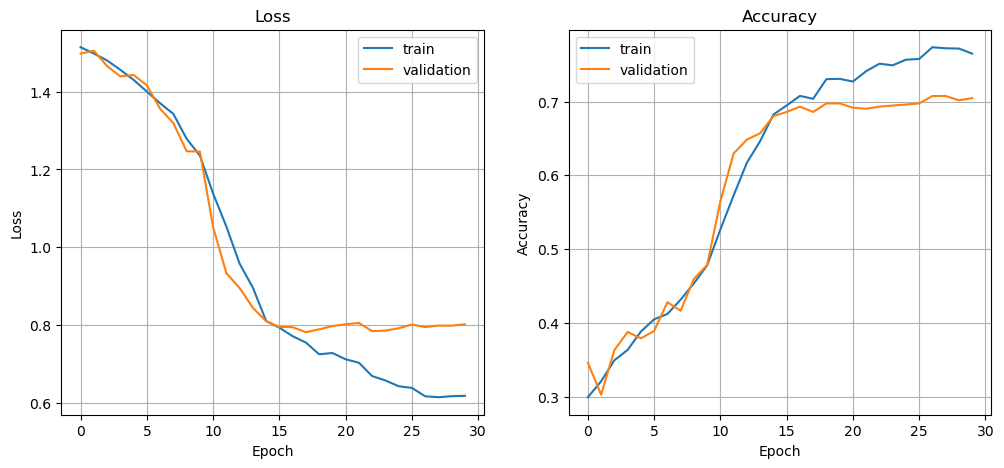

In [36]:
# plot the training and validation loss and accuracy curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

plt.show()

- Validation accuracy plateaus after ~ 20 epochs despite further improvement in train accuracy (sign of overfit)
- Model achieved ~ 70% accuracy in validation set: a good start

In [37]:
# print classification report and confusion matrix
print(classification_report(true_labels, pred_labels, target_names=label_encoder.classes_))

                      precision    recall  f1-score   support

    complex/multiple       0.64      0.55      0.59       206
        extra_letter       0.81      0.97      0.88        99
      missing_letter       0.76      0.93      0.83       209
phoneme_substitution       0.62      0.53      0.58       131
        substitution       0.52      0.31      0.38        49

            accuracy                           0.70       694
           macro avg       0.67      0.66      0.65       694
        weighted avg       0.69      0.70      0.69       694



In [38]:
# value counts for the true label classes in the original dataset
labelled_df['error_type'].value_counts().sort_values()

error_type
substitution             246
extra_letter             493
phoneme_substitution     653
complex/multiple        1029
missing_letter          1047
Name: count, dtype: int64

- Looking at the class predicitons, the model did worse on substituion and phoneme_substituion, which are lower on counts in the original dataset than the some other labels; perhaps balancing the label classes by oversampling or weights would help